In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from tqdm import tqdm

In [4]:
def f(t, v):

    m, n, k = v
    dmdt = -alpha*m * (2-n) - beta * m
    dndt = -n / tau_n + alpha * m * (1-n)
    dkdt = -k / tau_k + beta * m * (100-k) - xi * n * k

    return np.array([dmdt, dndt, dkdt])

100%|██████████| 4/4 [00:01<00:00,  3.73it/s]


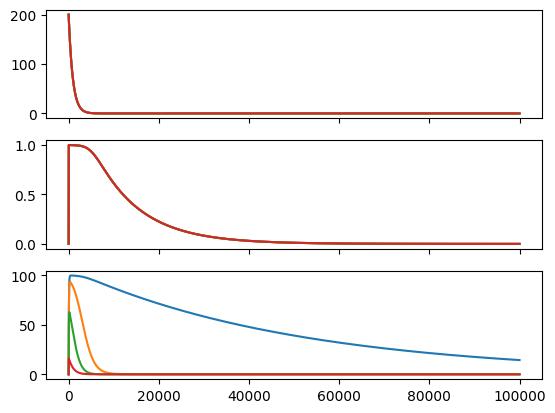

In [5]:
alpha = 10
beta = 1
tau_n = 1
tau_k = 5

dt = 1e-4
epochs = 100000

fig, axs = plt.subplots(3,1, sharex=True)
# axm = ax.twinx()

for xi in tqdm([0,10,100,1000]):
    
    # res = solve_ivp(f, t_span=[0,10], y0 = [2000,0,0])

    # # axm.plot(res.t, res.y[0])
    # ax.plot(res.t, res.y[1])
    # ax.plot(res.t, res.y[2])

    vs = [np.array([200,0,0])]

    for _ in range(epochs):
        vs.append(vs[-1] + f(0, vs[-1])*dt)

    vs = np.stack(vs, axis=1)

    axs[0].plot(vs[0])
    axs[1].plot(vs[1])
    axs[2].plot(vs[2])




100%|██████████| 3/3 [00:00<00:00,  3.77it/s]


(-1.0, 100.0)

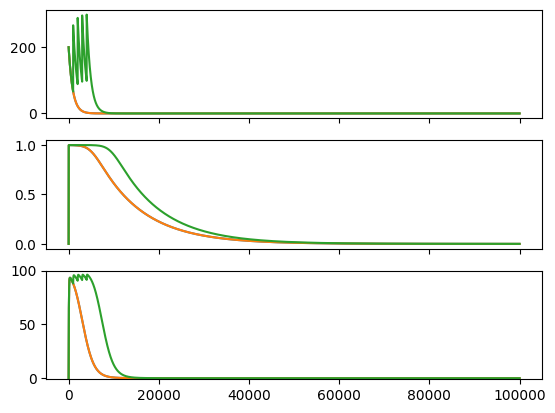

In [6]:
alpha = 10
beta = 1
tau_n = 1
tau_k = 5

dt = 1e-4
epochs = 100000

fig, axs = plt.subplots(3,1, sharex=True)
# axm = ax.twinx()

xi=10

for sigma in tqdm([100000, 10000, 1000]):
    
    # res = solve_ivp(f, t_span=[0,10], y0 = [2000,0,0])

    # # axm.plot(res.t, res.y[0])
    # ax.plot(res.t, res.y[1])
    # ax.plot(res.t, res.y[2])

    vs = [np.array([0,0,0])]

    for t in range(epochs):
        if t<5000 and not t%sigma: vs[-1][0] += 200 
        vs.append(vs[-1] + f(0, vs[-1])*dt)

    vs = np.stack(vs, axis=1)

    axs[0].plot(vs[0])
    axs[1].plot(vs[1])
    axs[2].plot(vs[2])


axs[2].set_ylim(-1,100)




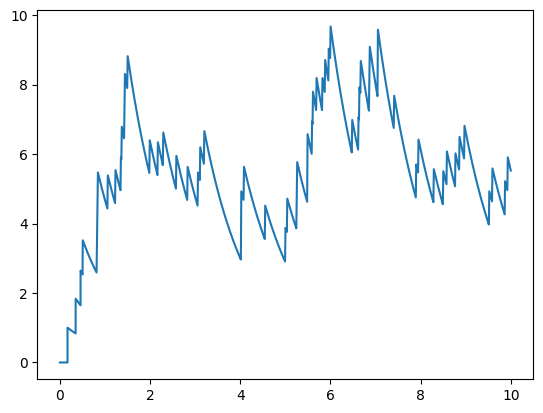

In [7]:
spike_intervals = np.random.exponential(.2, size=(100))
spike_ts = np.cumsum(spike_intervals)

def Theta(t):
    return (spike_ts < t).sum()


def g(t,x):
    return -k * x - k * m0 * Theta(t)

def m_from_x(t,x):
    '''not vectorized'''

    return x + m0 * Theta(t)

k = 1
m0 = 1
res = solve_ivp(g, t_span=(0,10), y0=(0,), method='BDF', 
                max_step=1e-2,
                )

# plt.plot(res.t, res.y[0])
m = []
for tt, xx in zip(res.t, res.y[0]):
    m.append(m_from_x(tt,xx))

plt.plot(res.t, m)


In [28]:
a = np.arange(10)
np.roll(a, 1)

array([9, 0, 1, 2, 3, 4, 5, 6, 7, 8])

In [54]:
def pplot(v, axs=None):

    x, y, z = v[-3:]

    if axs is None:
        fig = plt.figure(figsize=(8,2))
        axs = []
        for i in range(3):
            axs.append(fig.add_subplot(1,4,i+1))
            
        axs.append(fig.add_subplot(1,4,4,projection='3d'))

    axs[0].scatter(x,y, s=1)
    axs[1].scatter(y,z, s=1)
    axs[2].scatter(z,x, s=1)
    axs[3].scatter(x,y,z, s=1)

def get_pca(v):

    cov = v @ v.T
    eigvals, eigvecs = np.linalg.eigh(cov)

    vpca = eigvecs @ v 

    fig = plt.figure(figsize=(10,2))
    axs = []
    for i in range(4):
        axs.append(fig.add_subplot(1,5,i+1))
        
    axs.append(fig.add_subplot(1,5,5,projection='3d'))

    n_eigvals_to_plot = min(10, len(eigvals))

    axs[0].bar(range(n_eigvals_to_plot), eigvals[-n_eigvals_to_plot:])
    pplot(vpca, axs=axs[1:])


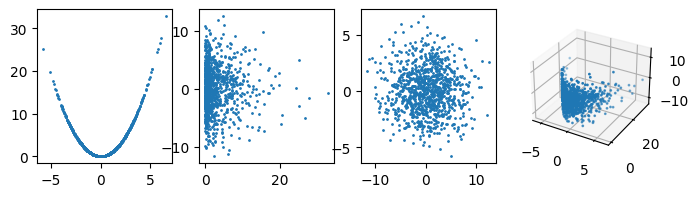

In [64]:
t = np.random.randn(1000)
s = np.random.randn(1000)

x = 2*t
y = 3*t**2
z = 4*s
v = np.stack([x,y,z], axis=0)

pplot(v)



Native PCA

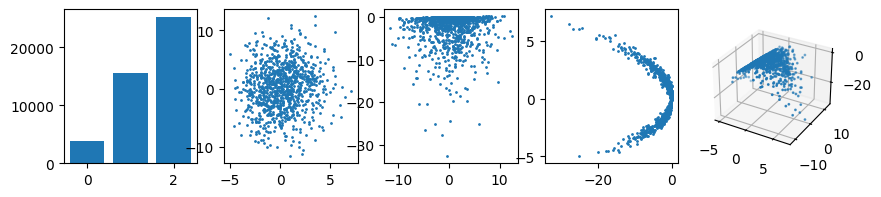

In [65]:
get_pca(v)


Random embedding

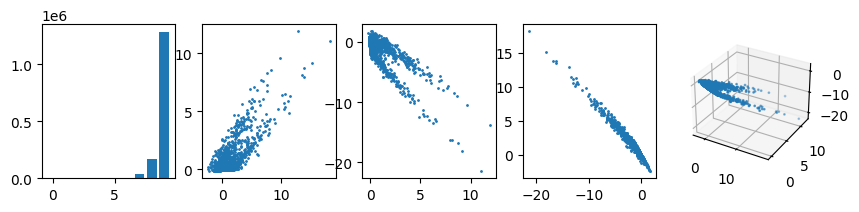

In [66]:
W = np.random.rand(100, 3)
w = W @ v

get_pca(w)

Delay embedding

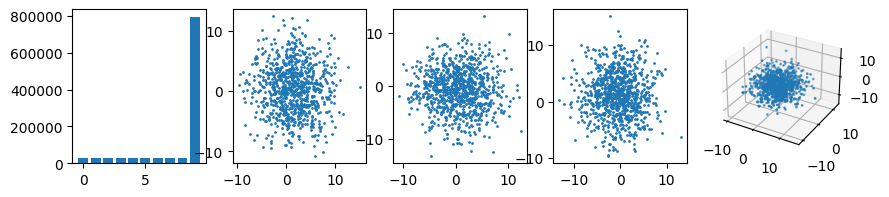

In [67]:
def dembed(v):

    ev = []
    for vv in v: 
        dvv = np.empty((100, len(vv)-100))
        for i in range(100):
            # print(dvv[i].shape,vv[i:i+900].shape)
            dvv[i] = vv[i:i+900]

        ev.append(dvv)

    return np.concatenate(ev, axis=0)

dv = dembed(v)

get_pca(dv)
        

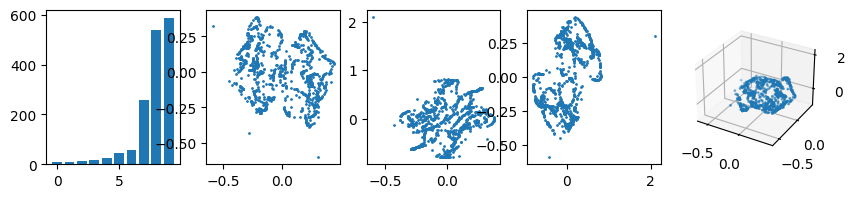

In [68]:
W = np.random.randn(20,20)
dt = 4e-1

v = np.empty((20,1000))
v[:,0] = np.random.randn(20)

for t in range(1,1000):
    v[:, t] = dt * np.tanh(W @ v[:, t-1])

get_pca(v)

Random embed

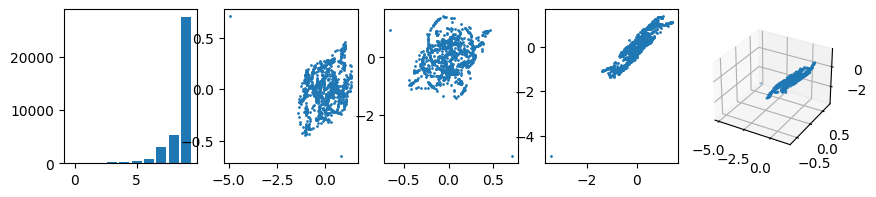

In [69]:
W = np.random.rand(100, 20)
w = W @ v

get_pca(w)

Delay embed

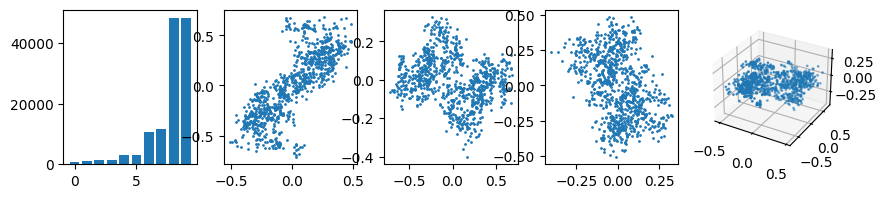

In [70]:
dv = dembed(v)
get_pca(dv)